# K-Drama Data Analysis Project

This project performs a complete data science workflow — from data cleaning to visualization — on the **Top 250 Korean Dramas** dataset (sourced from Kaggle).

## What was done:
- **Data Cleaning:** Handled missing values (Director, Screenwriter, Content Rating, Production companies), converted Duration and Rank columns into proper numeric formats
- **Database Integration:** Loaded the cleaned data into a MySQL database using Python (Pandas + SQLAlchemy)
- **Statistical Analysis:** Used NumPy to calculate mean, median, standard deviation, and correlation for Rating, Duration, and Episodes
- **Visualization:** Used Matplotlib to plot Rating distribution, Rating vs Episodes relationship, and Top 10 highest-rated dramas

## Key Insight:
Short-to-medium length dramas (10-20 episodes) generally have higher ratings compared to longer dramas (50+ episodes).

In [1]:
# Import required libraries for database connection and data handling
# Load environment variables from .env file (keeps credentials secure)

import numpy as np
from dotenv import load_dotenv
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
import pandas as pd
import matplotlib.pyplot as plt

load_dotenv()


True

In [2]:
# Load database credentials from .env file (username, password, host, database name)
# URL-encode the password since it contains special characters (@)
# Create a SQLAlchemy engine to connect to the MySQL database

DB_USER=os.getenv("DB_USER")
DB_PASSWORD=quote_plus(os.getenv("DB_PASSWORD"))
DB_HOST=os.getenv("DB_HOST")
DB_NAME=os.getenv("DB_NAME")

engine=create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}")

In [3]:
# Read the cleaned CSV file into a DataFrame
# Verify row count to confirm all data loaded correctly

df = pd.read_csv("clean_data.csv", encoding="utf-8")
print("Rows loaded:", len(df))

Rows loaded: 250


In [4]:
# Preview the first 5 rows to check data structure
df.head()

,Name,Aired Date,Year of release,Original Network,Aired On,Number of Episodes,Duration,Content Rating,Rating,Synopsis,Genre,Tags,Director,Screenwriter,Cast,Production companies,Rank
0,Move to Heaven,"May 14, 2021",2021,Netflix,Friday,10,52 min.,18+ Restricted (violence & profanity),9.2,Geu Roo is a young autistic man. He works for ...,"Life, Drama, Family","Autism, Uncle-Nephew Relationship, Death, Sava...",Kim Sung Ho,Yoon Ji Ryun,"Lee Je Hoon, Tang Jun Sang, Hong Seung Hee, Ju...","Page One Film, Number Three Pictures",#1
1,Flower of Evil,"Jul 29, 2020 - Sep 23, 2020",2020,tvN,"Wednesday, Thursday",16,1 hr. 10 min.,15+ - Teens 15 or older,9.1,Although Baek Hee Sung is hiding a dark secret...,"Thriller, Romance, Crime, Melodrama","Married Couple, Deception, Suspense, Family Se...","Kim Chul Gyu, Yoon Jong Ho",Yoo Jung Hee,"Lee Joon Gi, Moon Chae Won, Jang Hee Jin, Seo ...",Monster Union,#2
2,Hospital Playlist,"Mar 12, 2020 - May 28, 2020",2020,"Netflix, tvN",Thursday,12,1 hr. 30 min.,15+ - Teens 15 or older,9.1,The stories of people going through their days...,"Friendship, Romance, Life, Medical","Strong Friendship, Multiple Mains, Best Friend...",Shin Won Ho,Lee Woo Jung,"Jo Jung Suk, Yoo Yeon Seok, Jung Kyung Ho, Kim...","Egg Is Coming, CJ ENM",#3
3,Hospital Playlist 2,"Jun 17, 2021 - Sep 16, 2021",2021,"Netflix, tvN",Thursday,12,1 hr. 40 min.,15+ - Teens 15 or older,9.1,Everyday is extraordinary for five doctors and...,"Friendship, Romance, Life, Medical","Workplace, Strong Friendship, Best Friends, Mu...",Shin Won Ho,Lee Woo Jung,"Jo Jung Suk, Yoo Yeon Seok, Jung Kyung Ho, Kim...","Egg Is Coming, CJ ENM",#4
4,My Mister,"Mar 21, 2018 - May 17, 2018",2018,tvN,"Wednesday, Thursday",16,1 hr. 17 min.,15+ - Teens 15 or older,9.1,Park Dong Hoon is a middle-aged engineer who i...,"Psychological, Life, Drama, Family","Age Gap, Nice Male Lead, Strong Female Lead, H...","Kim Won Suk, Kim Sang Woo",Park Hae Young,"Lee Sun Kyun, IU, Park Ho San, Song Sae Byuk, ...",Chorokbaem Media,#5


In [5]:
# Push the DataFrame into MySQL as a table named 'kdramas'
# if_exists="replace" overwrites the table if it already exists
# index=False prevents Pandas' internal row index from being saved as a column

df.to_sql("kdramas", con=engine, if_exists="replace", index=False)
print("Data loaded to MYSQL")

Data loaded to MYSQL


In [6]:
# Read the data back from MySQL to confirm it was stored correctly

data = pd.read_sql("SELECT * from kdramas", con=engine)
# Check column data types and non-null counts

print(data.info())
# Check for missing values in each column

print("\ncheck is null\n", data.isnull().sum())
# Check for duplicate rows

print("\n check duplicated\n", data.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  250 non-null    str    
 1   Aired Date            250 non-null    str    
 2   Year of release       250 non-null    int64  
 3   Original Network      250 non-null    str    
 4   Aired On              250 non-null    str    
 5   Number of Episodes    250 non-null    int64  
 6   Duration              250 non-null    str    
 7   Content Rating        245 non-null    str    
 8   Rating                250 non-null    float64
 9   Synopsis              250 non-null    str    
 10  Genre                 250 non-null    str    
 11  Tags                  250 non-null    str    
 12  Director              249 non-null    str    
 13  Screenwriter          249 non-null    str    
 14  Cast                  250 non-null    str    
 15  Production companies  248 non-null

In [7]:
# Fill missing categorical values with "Unknown" since these are text fields
# with no logical numeric replacement (mean/median doesn't apply here)
data["Director"] = data["Director"].fillna("Unknown")
data["Screenwriter"] = data["Screenwriter"].fillna("Unknown")
data["Production companies"] = data["Production companies"].fillna("Unknown")

# Content Rating gets a distinct label since it's a meaningful category
# (e.g. "18+", "15+"), not just an unknown text field
data["Content Rating"] = data["Content Rating"].fillna("Not Rated")

# Verify all missing values have been handled
print(data.isnull().sum())

Name                    0
Aired Date              0
Year of release         0
Original Network        0
Aired On                0
Number of Episodes      0
Duration                0
Content Rating          0
Rating                  0
Synopsis                0
Genre                   0
Tags                    0
Director                0
Screenwriter            0
Cast                    0
Production companies    0
Rank                    0
dtype: int64


In [8]:
# Only convert if still in string/object format
if not pd.api.types.is_integer_dtype(data["Rank"]):
    data["Rank"]=data["Rank"].str.replace("#","").astype(int)

data.tail(3)

,Name,Aired Date,Year of release,Original Network,Aired On,Number of Episodes,Duration,Content Rating,Rating,Synopsis,Genre,Tags,Director,Screenwriter,Cast,Production companies,Rank
247,Memory,"Mar 18, 2016 - May 7, 2016",2016,tvN,"Friday, Saturday",16,1 hr. 5 min.,15+ - Teens 15 or older,8.3,Park Tae Suk is a lawyer who finds out that he...,"Law, Romance, Life, Drama","Alzheimer's Disease, Teamwork, Bromance, Mothe...",Park Chan Hong,Kim Ji Woo,"Lee Sung Min, Kim Jee Soo, Park Jin Hee, Lee J...",MI Inc.,248
248,A Korean Odyssey,"Dec 23, 2017 - Mar 4, 2018",2017,"Netflix, tvN","Saturday, Sunday",20,1 hr. 20 min.,15+ - Teens 15 or older,8.3,"In 2017, Son Oh Gong and Ma Wang are in confli...","Horror, Comedy, Romance, Fantasy","Ghost-seeing Female Lead, Special Power, Super...","Park Hong Kyun, Kim Jung Hyun, Kim Byung Soo","Hong Jung Eun, Hong Mi Ran","Lee Seung Gi, Cha Seung Won, Oh Yeon Seo, Lee ...",JS Pictures,249
249,Voice 4: Judgment Hour,"Jun 18, 2021 - Jul 31, 2021",2021,tvN,"Friday, Saturday",14,1 hr. 3 min.,15+ - Teens 15 or older,8.3,A serial killer with an enhanced hearing abili...,"Action, Thriller, Mystery, Crime","Investigation, Suspense, Animal Abuse, Psychol...","Shin Yong Hwi, Yoon Ra Young",Ma Jin Won,"Lee Ha Na, Song Seung Heon, Son Eun Seo, Kang...",Story & Pictures Media,250


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  250 non-null    str    
 1   Aired Date            250 non-null    str    
 2   Year of release       250 non-null    int64  
 3   Original Network      250 non-null    str    
 4   Aired On              250 non-null    str    
 5   Number of Episodes    250 non-null    int64  
 6   Duration              250 non-null    str    
 7   Content Rating        250 non-null    str    
 8   Rating                250 non-null    float64
 9   Synopsis              250 non-null    str    
 10  Genre                 250 non-null    str    
 11  Tags                  250 non-null    str    
 12  Director              250 non-null    str    
 13  Screenwriter          250 non-null    str    
 14  Cast                  250 non-null    str    
 15  Production companies  250 non-null

In [ ]:
# Convert the "Duration" column (text format like "1 hr. 10 min.") into total minutes.
# Extract hours and minutes separately using regex, fill missing matches with 0,
# then combine them into a single numeric "Duration_Minutes" column for analysis.

hours=data["Duration"].str.extract(r"(\d+)\s*hr").fillna(0).astype(int)
minutes=data["Duration"].str.extract(r"(\d+)\s*min").fillna(0).astype(int)

# calculate  Total minutes 

data["Duration_Minutes"]=hours[0] * 60 + minutes[0]

data[["Duration","Duration_Minutes"]].head(10)

,Duration,Duration_Minutes
0,52 min.,52
1,1 hr. 10 min.,70
2,1 hr. 30 min.,90
3,1 hr. 40 min.,100
4,1 hr. 17 min.,77
5,1 hr. 40 min.,100
6,40 min.,40
7,1 hr. 32 min.,92
8,1 hr. 20 min.,80
9,1 hr. 17 min.,77


In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  250 non-null    str    
 1   Aired Date            250 non-null    str    
 2   Year of release       250 non-null    int64  
 3   Original Network      250 non-null    str    
 4   Aired On              250 non-null    str    
 5   Number of Episodes    250 non-null    int64  
 6   Duration              250 non-null    str    
 7   Content Rating        250 non-null    str    
 8   Rating                250 non-null    float64
 9   Synopsis              250 non-null    str    
 10  Genre                 250 non-null    str    
 11  Tags                  250 non-null    str    
 12  Director              250 non-null    str    
 13  Screenwriter          250 non-null    str    
 14  Cast                  250 non-null    str    
 15  Production companies  250 non-null

In [ ]:
# Save the fully cleaned dataset for future use.
# Export to a CSV file for backup, and also save it into MySQL as a new table
# ("kdramas_clean") so the original raw table remains untouched.


data.to_csv("Kdramas_final_clean.csv",index=False)

data.to_sql("kdramas_clean",con=engine,if_exists="replace",index=False)


print("Cleaned data saved successfully!")

Cleaned data saved successfully!


In [ ]:
# Convert Rating, Duration, and Number of Episodes columns into NumPy arrays,
# then calculate key statistics (mean, median, standard deviation, min, max)
# for each. Results are printed in a clean, organized format.


ratings=data["Rating"].to_numpy()
duration=data["Duration_Minutes"].to_numpy()
episodes=data["Number of Episodes"].to_numpy()

mean_rating=np.mean(ratings)
median_rating=np.median(ratings)
std_deviation_rating=np.std(ratings)
min_rating=np.min(ratings)
max_rating=np.max(ratings)


mean_duration=np.mean(duration)
median_duration=np.median(duration)
std_deviation_duration=np.std(duration)
min_duration=np.min(duration)
max_duration=np.max(duration)


mean_episodes=np.mean(episodes)
median_episodes=np.median(episodes)
std_deviation_episodes=np.std(episodes)
min_episodes=np.min(episodes)
max_episodes=np.max(episodes)


print("="*50)
print("RATING STATISTICS")
print("="*50)
print(f"Mean:               {mean_rating:.2f}")
print(f"Median:              {median_rating:.2f}")
print(f"Standard Deviation:  {std_deviation_rating:.2f}")
print(f"Minimum:             {min_rating:.2f}")
print(f"Maximum:             {max_rating:.2f}")

print("\n" + "="*50)
print("DURATION STATISTICS (in minutes)")
print("="*50)
print(f"Mean:                {mean_duration:.2f}")
print(f"Median:              {median_duration:.2f}")
print(f"Standard Deviation:  {std_deviation_duration:.2f}")
print(f"Minimum:             {min_duration}")
print(f"Maximum:             {max_duration}")

print("\n" + "="*50)
print("EPISODES STATISTICS")
print("="*50)
print(f"Mean:                {mean_episodes:.2f}")
print(f"Median:              {median_episodes:.2f}")
print(f"Standard Deviation:  {std_deviation_episodes:.2f}")
print(f"Minimum:             {min_episodes}")
print(f"Maximum:             {max_episodes}")


RATING STATISTICS
Mean:               8.53
Median:              8.50
Standard Deviation:  0.22
Minimum:             8.30
Maximum:             9.20

DURATION STATISTICS (in minutes)
Mean:                62.41
Median:              65.00
Standard Deviation:  14.93
Minimum:             15
Maximum:             100

EPISODES STATISTICS
Mean:                19.06
Median:              16.00
Standard Deviation:  13.22
Minimum:             1
Maximum:             133


In [14]:
# Rating vs Episodes correlation

corr_rating_episodes=np.corrcoef(ratings,episodes)[0,1]

# Rating vs Duration correlation

corr_rating_duration=np.corrcoef(ratings,duration)[0,1]

print(f"Correlation (Rating vs Episodes): {corr_rating_episodes:.3f}")
print(f"Correlation (Rating vs Duration): {corr_rating_duration:.3f}")

Correlation (Rating vs Episodes): -0.097
Correlation (Rating vs Duration): 0.295


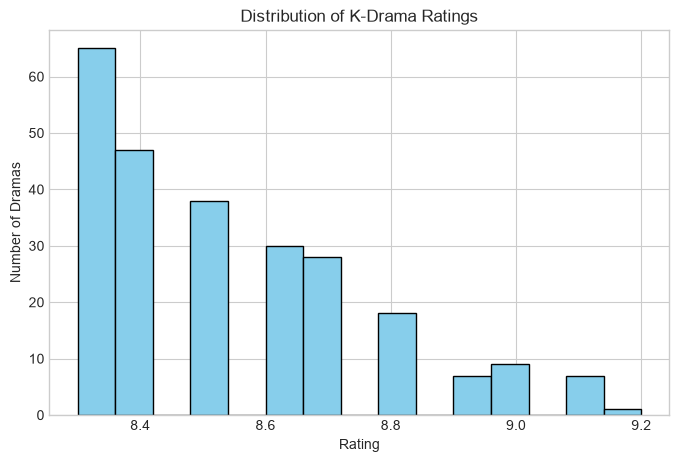

In [19]:
# Rating Distribution (Histogram)

plt.figure(figsize=(8,5))

plt.hist(ratings,bins=15, color="skyblue",edgecolor="black")
plt.title("Distribution of K-Drama Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Dramas")
plt.grid(True,axis="y")
plt.savefig("rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

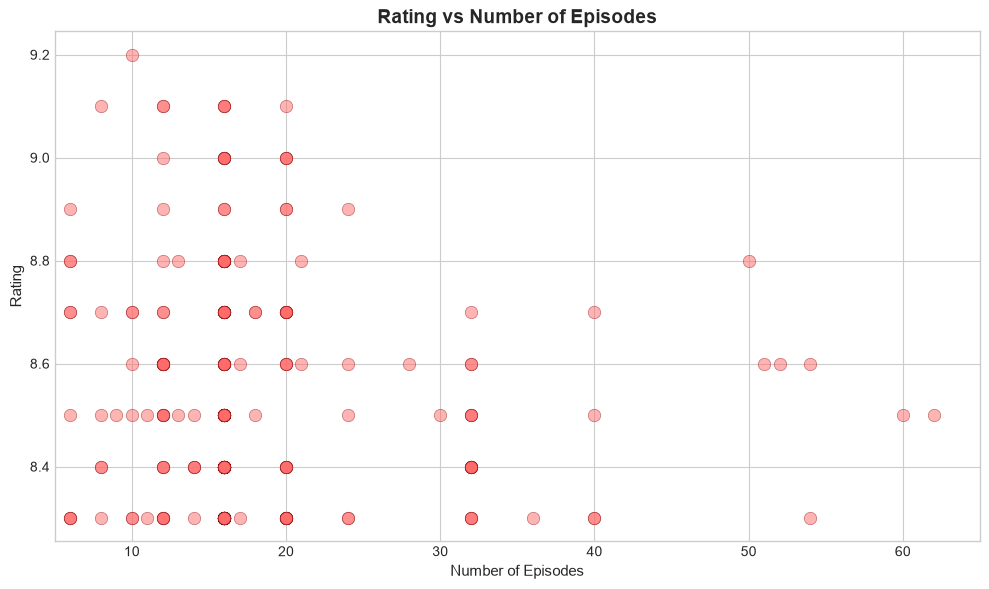

In [20]:
# Scatter plot: Rating vs Number of Episodes.
plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(10, 6))
plt.scatter(episodes, ratings, 
            color="#FF6B6B", 
            alpha=0.5, 
            s=80, 
            edgecolor="darkred", 
            linewidth=0.5)

plt.title("Rating vs Number of Episodes", fontsize=14, fontweight="bold")
plt.xlabel("Number of Episodes", fontsize=11)
plt.ylabel("Rating", fontsize=11)
plt.xlim(5,65)
plt.tight_layout()
plt.savefig("rating_vs_episodes.png", dpi=300, bbox_inches="tight")
plt.show()

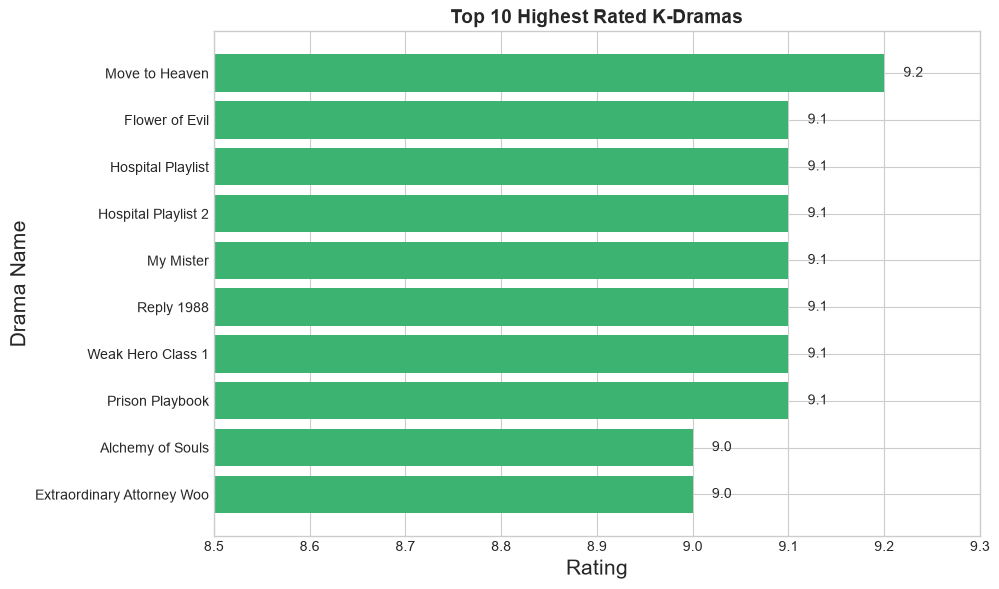

In [21]:
# Top 10 highest-rated dramas.

top10 = data.nlargest(10, "Rating")

plt.figure(figsize=(10, 6))
bars=plt.barh(top10["Name"], top10["Rating"], color="mediumseagreen")
plt.title("Top 10 Highest Rated K-Dramas", fontsize=14, fontweight="bold")
plt.xlabel("Rating",fontsize=15)
plt.ylabel("Drama Name",fontsize=15)
plt.gca().invert_yaxis()  # highest rating sabse upar dikhe
plt.tight_layout()
plt.xlim(8.5,9.3)

for bar in bars:
    width=bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height() / 2,
    f"{width:.1f}",
    va="center",fontsize=10
    )
plt.savefig("top10_dramas.png", dpi=300, bbox_inches="tight")    
plt.show()